#### Problem Statement

Linear regression by using Deep Neural network: Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

#### Description of dataset


   The dataset used in this project comes from the UCI Machine Learning Repository. This data was collected in 1978 and each of the 506 entries represents aggregate information about 14 features of homes from various suburbs located in Boston.

The features can be summarized as follows:
* CRIM: This is the per capita crime rate by town
* ZN: This is the proportion of residential land zoned for lots larger than 25,000 sq.ft.
* INDUS: This is the proportion of non-retail business acres per town.
* CHAS: This is the Charles River dummy variable (this is equal to 1 if tract bounds river; 0 otherwise)
* NOX: This is the nitric oxides concentration (parts per 10 million)
* RM: This is the average number of rooms per dwelling
* AGE: This is the proportion of owner-occupied units built prior to 1940
* DIS: This is the weighted distances to five Boston employment centers
* RAD: This is the index of accessibility to radial highways
* TAX: This is the full-value property-tax rate per 1000 bucks
* PTRATIO: This is the pupil-teacher ratio by town
* B: This is calculated as 1000(Bk — 0.63)², where Bk is the proportion of people of African American descent by town
* LSTAT: This is the percentage lower status of the population
* PRICE/MEDV: This is the median value of owner-occupied homes in 1000s

In [205]:
import pandas as pd

In [206]:
#import DNN libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense

In [207]:
df = pd.read_csv('Boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT. MEDV,Unnamed: 15,Unnamed: 16
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0,NaN,NaN
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0,NaN,NaN
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1,NaN,NaN
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1,NaN,NaN
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1,NaN,NaN


In [208]:
#Drop unnecessary columns
df = df.dropna(axis=1)
df = df.drop(columns=['CAT. MEDV', 'CHAS'])
df.head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [209]:
#Rename Column name MEDV as PRICE
df = df.rename(columns={'MEDV': 'PRICE'})
df.head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [210]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


In [211]:
#Data exploration
print("Shape of the dataset: ",df.shape)
print(df.dtypes)


Shape of the dataset:  (506, 13)
CRIM       float64
ZN         float64
INDUS      float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object


<Axes: >

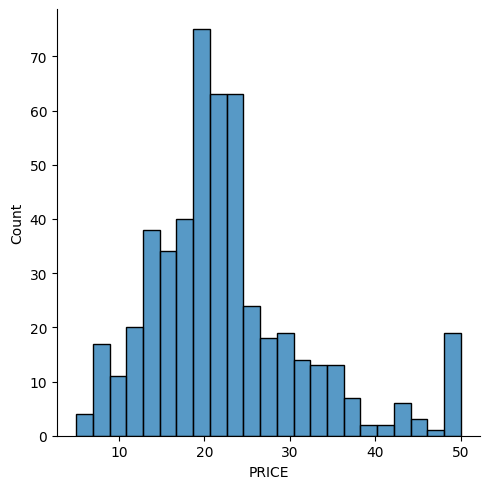

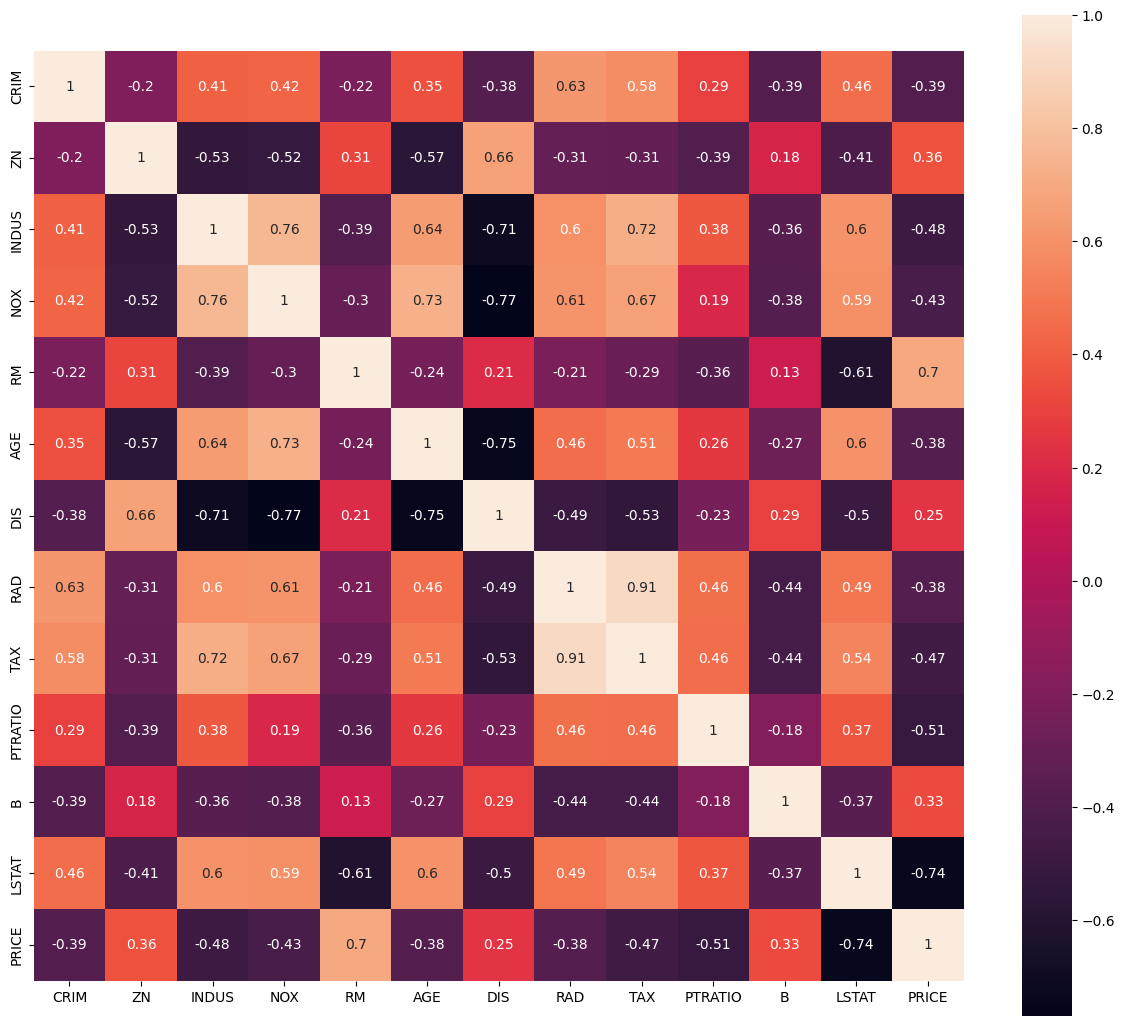

In [212]:
# Data Visualization
import seaborn as sns
sns.displot(df.PRICE)

correlation = df.corr()
correlation.loc['PRICE']

fig,axes = plt.subplots(figsize=(15,13))
sns.heatmap(correlation,square = True,annot = True)

In [213]:
for k in df.columns:
    q1 = df[k].quantile(0.25)
    q3 = df[k].quantile(0.75)
    iqr = q3 - q1

    df = df[(df[k] >= q1 - 1.5 * iqr) & (df[k] <= q3 + 1.5 * iqr)]
    perc = np.shape(v_col)[0] * 100.0 / np.shape(df)[0]
    print("Column %s outliers = %.2f%%" % (k, perc))

Column CRIM outliers = 2.27%
Column ZN outliers = 2.53%
Column INDUS outliers = 2.53%
Column NOX outliers = 2.64%
Column RM outliers = 2.80%
Column AGE outliers = 2.80%
Column DIS outliers = 2.83%
Column RAD outliers = 3.46%
Column TAX outliers = 3.52%
Column PTRATIO outliers = 3.52%
Column B outliers = 3.91%
Column LSTAT outliers = 4.00%
Column PRICE outliers = 4.33%


In [232]:
# Train test split for model training 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 4)

#Normalizing the data
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [233]:
# Model Building
model = Sequential()

model.add(Dense(128,activation  = 'relu',input_dim =12))
model.add(Dense(64,activation  = 'relu'))
model.add(Dense(32,activation  = 'relu'))
model.add(Dense(16,activation  = 'relu'))
model.add(Dense(1))

# #Compile
model.compile(optimizer = 'adam',loss = 'mean_squared_error')

model.summary()


/home/naveed-malik/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

In [234]:
history = model.fit(X_train,y_train,epochs=90,batch_size=32,validation_data=[X_test,y_test])

Epoch 1/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 529.8752 - val_loss: 453.1322
Epoch 2/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 501.8967 - val_loss: 425.8962
Epoch 3/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 464.0020 - val_loss: 383.2437
Epoch 4/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 405.8180 - val_loss: 318.1764
Epoch 5/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 323.7926 - val_loss: 230.0531
Epoch 6/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 220.3840 - val_loss: 130.2853
Epoch 7/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 111.4619 - val_loss: 58.0762
Epoch 8/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 48.7005 - val_loss: 53.9875
Epoch 9/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 49.6978 - val_loss: 52.8080
Epoch 10/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 38.7989 - val_loss: 35.7854
Epoch 11/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25.9780 - val_loss: 31.6429
Epoch 12/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

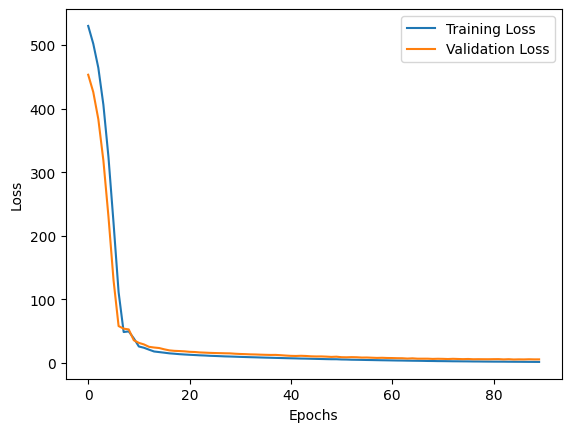

In [235]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [236]:
# Evaluating the model
from sklearn.metrics import mean_squared_error,r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = (np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score = ", r2)
print("RMSE Score = ", rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
R2 Score =  0.6614326201692102
RMSE Score =  2.3896650503126353
